In [1]:
import os
print(os.getcwd())
os.environ["NUPLAN_MAPS_ROOT"] = os.path.expandvars("$HOME/Code/navsim/dataset/maps")
# os.environ["NAVSIM_EXP_ROOT"] = os.path.expandvars("$HOME/Code/navsim/exp")
# os.environ["NAVSIM_DEVKIT_ROOT"] = os.path.expandvars("$HOME/Code/navsim/GTRS")
os.environ["OPENSCENE_DATA_ROOT"] = os.path.expandvars("$HOME/Code/navsim/dataset")
# os.environ["NAVSIM_TRAJPDM_ROOT"] = os.path.expandvars("$HOME/Code/navsim/dataset/traj_pdm_v2")

from pathlib import Path

import hydra
from hydra.utils import instantiate
import matplotlib.pyplot as plt

from navsim.common.dataloader import SceneLoader
from navsim.common.dataclasses import SceneFilter, SensorConfig
from hydra.core.global_hydra import GlobalHydra
SPLIT = "mini"  # ["mini", "test", "trainval"]
FILTER = "all_scenes"
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()
hydra.initialize(config_path="../navsim/planning/script/config/common/train_test_split/scene_filter")
cfg = hydra.compose(config_name=FILTER)
print(cfg)
scene_filter: SceneFilter = instantiate(cfg)
# scene_filter.max_scenes = 8
openscene_data_root = Path(os.getenv("OPENSCENE_DATA_ROOT"))

scene_loader = SceneLoader(
    openscene_data_root / f"navsim_logs/{SPLIT}", # data_path
    openscene_data_root / f"sensor_blobs/{SPLIT}", # original_sensor_path
    scene_filter,
    openscene_data_root / "warmup_two_stage/sensor_blobs", # synthetic_sensor_path
    openscene_data_root / "warmup_two_stage/synthetic_scene_pickles", # synthetic_scenes_path
    sensor_config=SensorConfig.build_all_sensors(),
)

/Users/chenran/Code/e2e_av_from_scratch/phase-2 model


/var/folders/1k/q487h1g17y79bb1bj_jrhl5w0000gn/T/ipykernel_31521/3757473776.py:22: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize(config_path="../navsim/planning/script/config/common/train_test_split/scene_filter")


{'_target_': 'navsim.common.dataclasses.SceneFilter', '_convert_': 'all', 'num_history_frames': 4, 'num_future_frames': 10, 'frame_interval': None, 'has_route': True, 'max_scenes': None, 'log_names': None, 'tokens': None}


Loading logs: 100%|██████████| 64/64 [00:01<00:00, 33.06it/s]


In [6]:
from transfuer import TransfuserModel, TRANSFUSER_CONFIG
import torch
ckpt = torch.load('../model_weights/transfuser_seed/transfuser_seed_2.ckpt', map_location='cpu')
state_dict = ckpt['state_dict']
state_dict = {
    k.replace("agent._transfuser_model.", ""): v
    for k, v in state_dict.items()
    if k.startswith("agent._transfuser_model.")
}

model = TransfuserModel(TRANSFUSER_CONFIG)
model.load_state_dict(state_dict, strict=True)

<All keys matched successfully>

In [7]:
from dataset import Dataset
from dataset import DatasetV2
from torch.utils.data.dataloader import DataLoader

dataset = Dataset(scene_loader=scene_loader, max_len=8, random_sample=False)
sample_idx = 0
sample_token = dataset.tokens[sample_idx]
data_loader = DataLoader(dataset=dataset, batch_size=1, shuffle=False)

for batch_idx, (token, features, targets) in enumerate(data_loader):
    if batch_idx != sample_idx:
        continue
    print(features.keys())
    print(features['camera_feature'].shape, features['lidar_feature'].shape, features['status_feature'])
    print(targets.keys())
    output = model(features)
    break


dict_keys(['camera_feature', 'lidar_feature', 'status_feature'])
torch.Size([1, 3, 256, 1024]) torch.Size([1, 1, 256, 256]) tensor([[ 0.0000,  0.0000,  0.0000,  1.0000, -0.0090, -0.0017, -0.0471, -0.0300]])
dict_keys(['trajectory', 'agent_states', 'agent_labels', 'bev_semantic_map'])


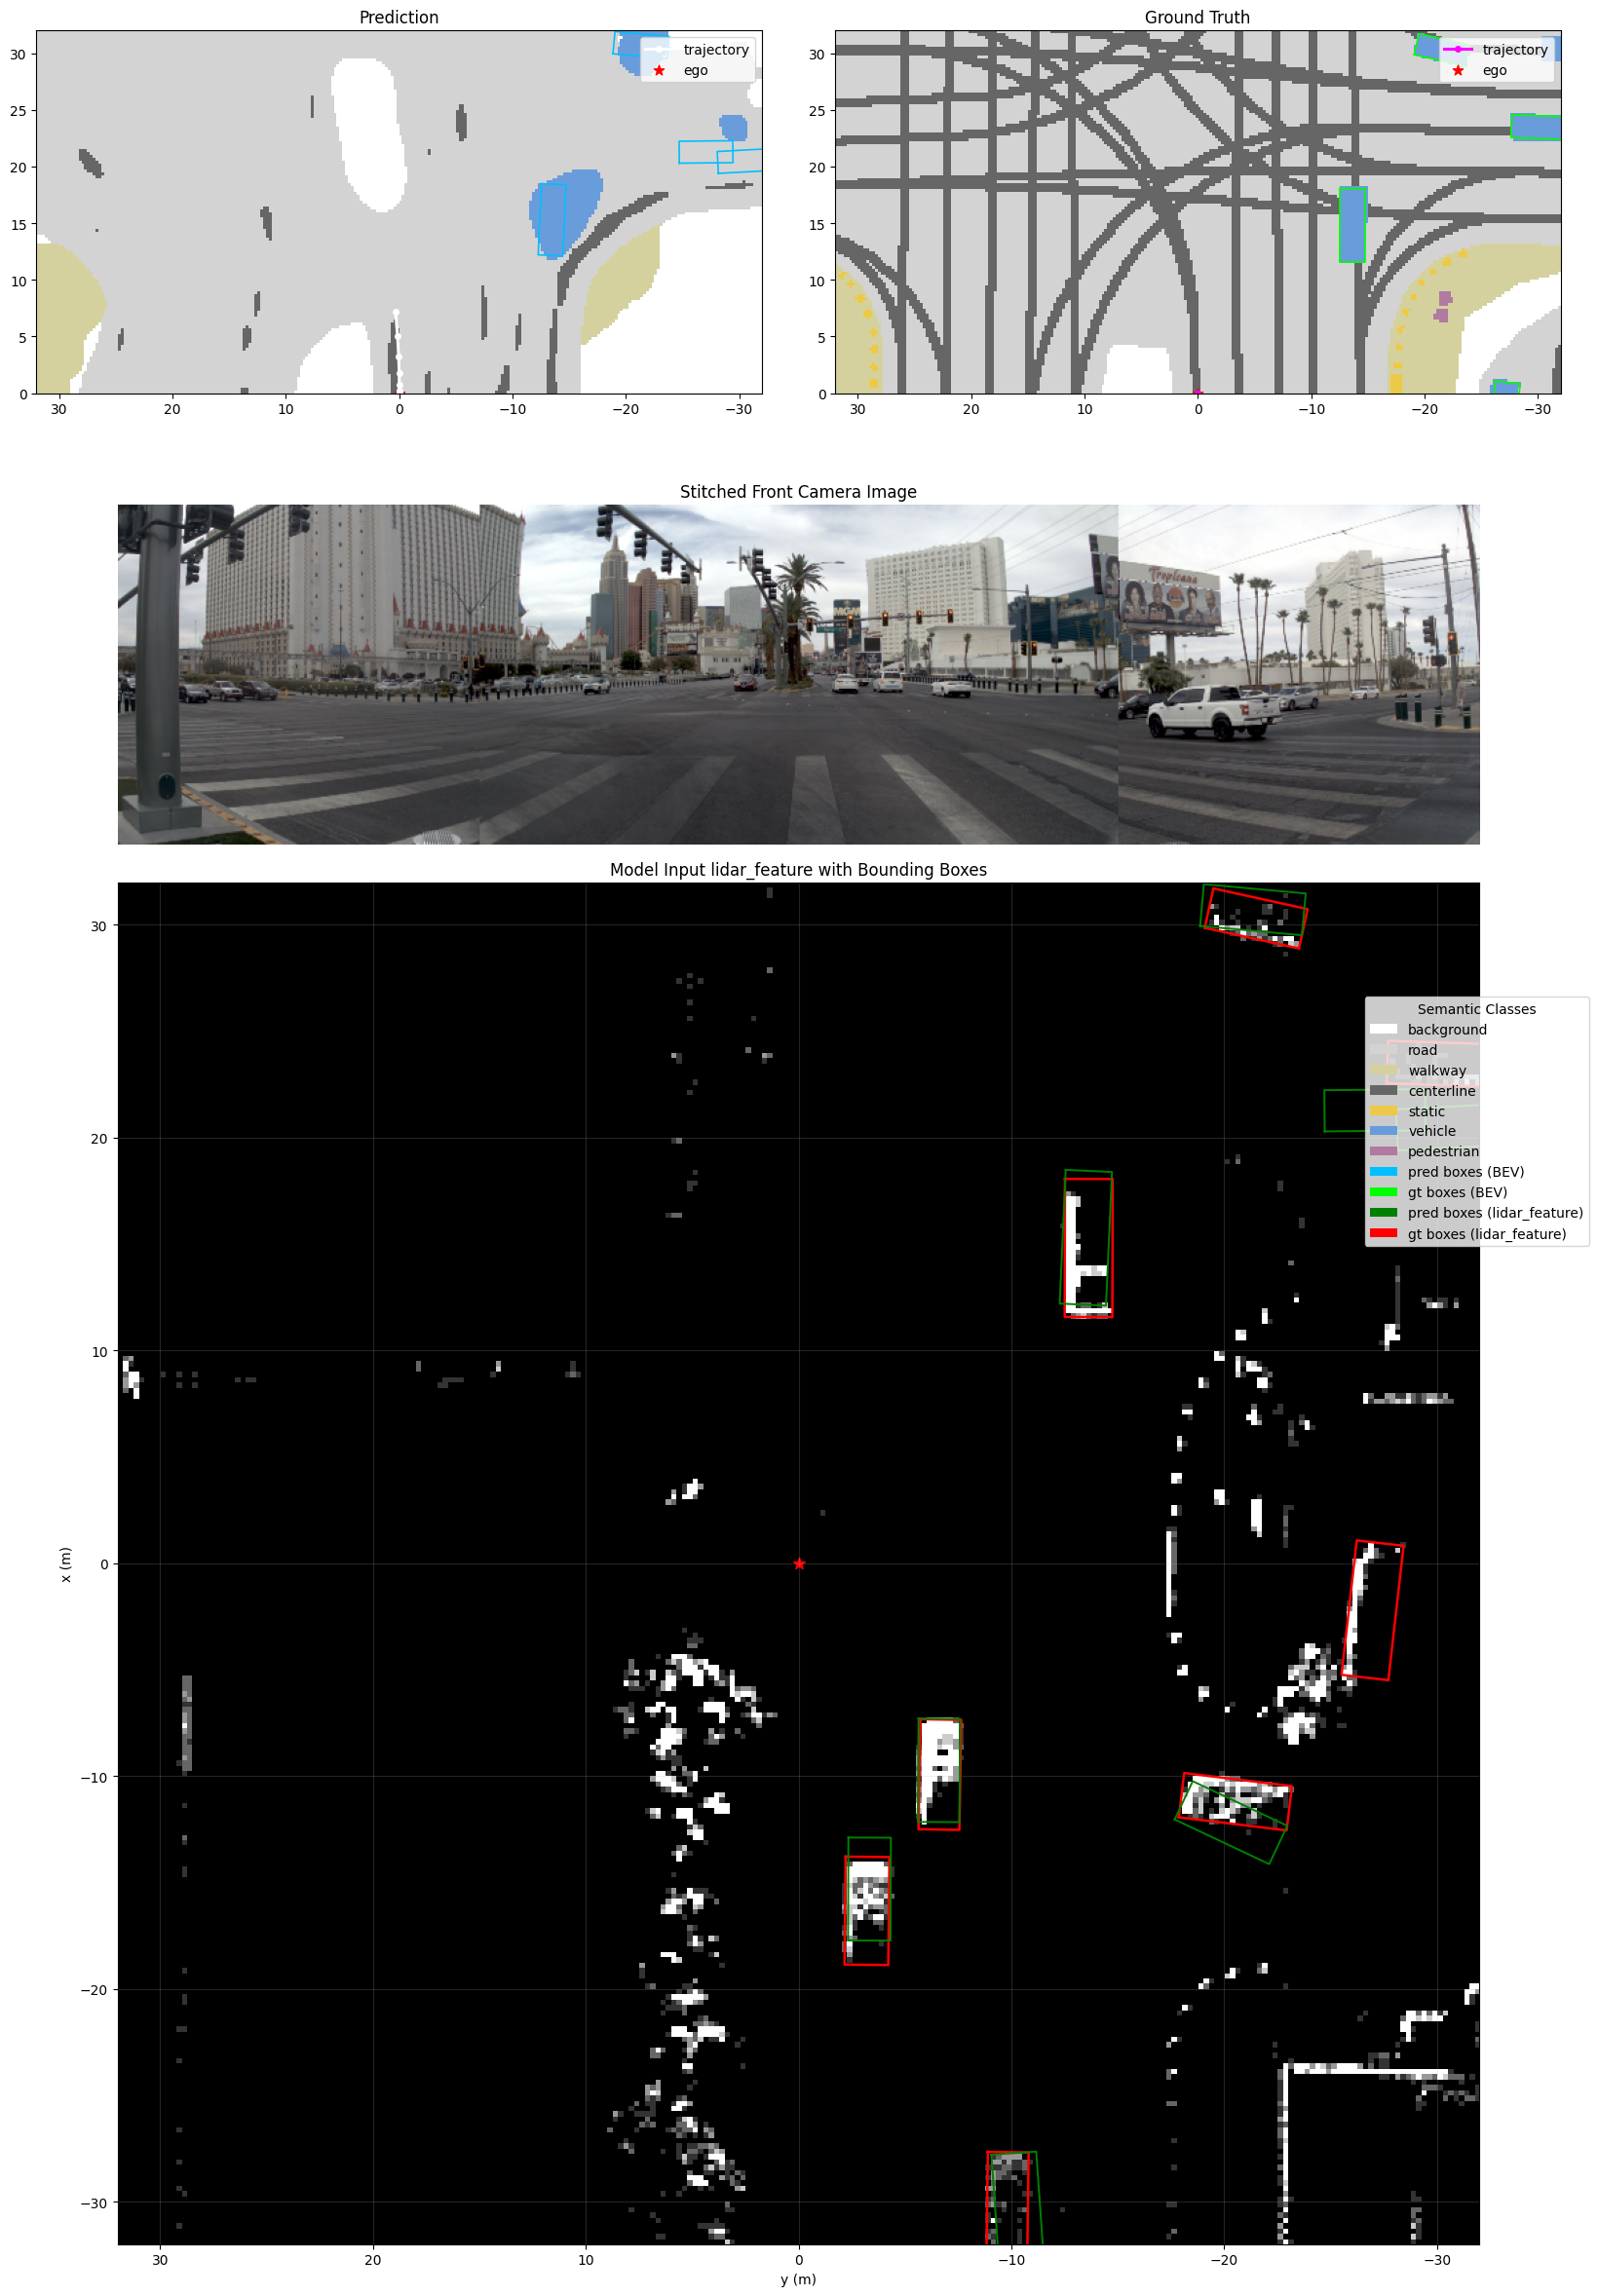

In [8]:
def show_result(output, targets, features):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch, Rectangle

    pred_bev = output['bev_semantic_map'][0].detach().cpu().numpy().argmax(axis=0)
    pred_traj = output['trajectory'][0].detach().cpu().numpy()
    pred_boxes = output['agent_states'][0].detach().cpu().numpy()
    pred_scores = output['agent_labels'][0].detach().cpu().numpy()

    gt_bev = targets['bev_semantic_map'][0].detach().cpu().numpy()
    gt_traj = targets['trajectory'][0].detach().cpu().numpy()
    gt_boxes = targets['agent_states'][0].detach().cpu().numpy()
    gt_scores = targets['agent_labels'][0].detach().cpu().numpy()
    camera_image = features['camera_feature'][0].detach().cpu().permute(1, 2, 0).numpy()
    lidar_feature = features['lidar_feature'][0, 0].detach().cpu().numpy()

    PIXELS_PER_METER = 4.0
    Y_MIN = -32.0
    X_MAX = 32.0
    BEV_WIDTH = pred_bev.shape[1]
    BEV_HEIGHT = pred_bev.shape[0]
    Y_MAX = Y_MIN + BEV_WIDTH / PIXELS_PER_METER
    X_MIN = X_MAX - BEV_HEIGHT / PIXELS_PER_METER

    def ego_to_pixel(x, y):
        px = (y - Y_MIN) * PIXELS_PER_METER
        py = (X_MAX - x) * PIXELS_PER_METER
        return px, py

    def plot_box(ax, box, color, linewidth=1.5):
        corners = box_corners_xy(box)
        ax.plot(corners[:, 1], corners[:, 0], color=color, linewidth=linewidth)

    def box_corners_xy(box):
        x, y, heading, length, width = box
        local = np.array([
            [ length / 2,  width / 2],
            [ length / 2, -width / 2],
            [-length / 2, -width / 2],
            [-length / 2,  width / 2],
            [ length / 2,  width / 2],
        ])
        rot = np.array([
            [np.cos(heading), -np.sin(heading)],
            [np.sin(heading),  np.cos(heading)],
        ])
        return local @ rot.T + np.array([x, y])

    def plot_traj(ax, traj, color, label, linestyle='-', marker='o'):
        ax.plot(traj[:, 1], traj[:, 0], color=color, linewidth=2.2, linestyle=linestyle, marker=marker, markersize=4, label=label)

    def draw_panel(ax, bev_map, boxes, scores, traj, title, box_color, traj_color):
        ax.imshow(
            bev_map,
            cmap=ListedColormap(class_colors),
            interpolation='nearest',
            origin='lower',
            extent=[Y_MIN, Y_MAX, X_MIN, X_MAX],
            vmin=0,
            vmax=len(class_colors) - 1,
        )
        valid_mask = scores > 0
        for box in boxes[valid_mask]:
            plot_box(ax, box, color=box_color, linewidth=1.2)
        plot_traj(ax, traj, color=traj_color, label='trajectory')
        ax.scatter(0.0, 0.0, color='red', s=60, marker='*', label='ego')
        ax.set_title(title)
        ax.set_xlim(Y_MIN, Y_MAX)
        ax.set_ylim(X_MIN, X_MAX)
        ax.invert_xaxis()
        ax.set_aspect('equal')
        ax.legend(loc='upper right')

    class_names = ['background', 'road', 'walkway', 'centerline', 'static', 'vehicle', 'pedestrian']
    class_colors = ['#FFFFFF', '#D3D3D3', '#d4d19e', '#666666', '#edc948', '#699CDB', '#b07aa1']
    class_handles = [Patch(facecolor=color, edgecolor='none', label=name) for name, color in zip(class_names, class_colors)]
    overlay_handles = [
        Patch(facecolor='deepskyblue', edgecolor='none', label='pred boxes (BEV)'),
        Patch(facecolor='lime', edgecolor='none', label='gt boxes (BEV)'),
        Patch(facecolor='green', edgecolor='none', label='pred boxes (lidar_feature)'),
        Patch(facecolor='red', edgecolor='none', label='gt boxes (lidar_feature)'),
    ]

    fig = plt.figure(figsize=(16, 24), constrained_layout=True)
    gs = fig.add_gridspec(3, 2, height_ratios=[3, 2, 8])
    ax_pred = fig.add_subplot(gs[0, 0])
    ax_gt = fig.add_subplot(gs[0, 1])
    ax_cam = fig.add_subplot(gs[1, :])
    ax_lidar = fig.add_subplot(gs[2, :])

    draw_panel(ax_pred, pred_bev, pred_boxes, pred_scores, pred_traj, 'Prediction', 'deepskyblue', 'white')
    draw_panel(ax_gt, gt_bev, gt_boxes, gt_scores, gt_traj, 'Ground Truth', 'lime', 'magenta')

    ax_cam.imshow(camera_image)
    ax_cam.set_title('Stitched Front Camera Image')
    ax_cam.axis('off')

    ax_lidar.imshow(lidar_feature, cmap='gray', origin='lower', extent=[-32, 32, -32, 32])
    for box in gt_boxes[gt_scores > 0]:
        corners = box_corners_xy(box)
        ax_lidar.plot(corners[:, 1], corners[:, 0], color='red', linewidth=1.8)
    for box in pred_boxes[pred_scores > 0]:
        corners = box_corners_xy(box)
        ax_lidar.plot(corners[:, 1], corners[:, 0], color='green', linewidth=1.4)
    ax_lidar.scatter(0.0, 0.0, color='red', s=80, marker='*')
    ax_lidar.set_title('Model Input lidar_feature with Bounding Boxes')
    ax_lidar.set_xlabel('y (m)')
    ax_lidar.set_ylabel('x (m)')
    ax_lidar.set_xlim(-32, 32)
    ax_lidar.set_ylim(-32, 32)
    ax_lidar.invert_xaxis()
    ax_lidar.set_box_aspect(lidar_feature.shape[0] / lidar_feature.shape[1])
    ax_lidar.grid(True, alpha=0.2)
    ax_lidar.set_facecolor('#111111')

    fig.legend(handles=class_handles + overlay_handles, loc='center right', bbox_to_anchor=(1.02, 0.5), frameon=True, title='Semantic Classes')
    plt.show()

show_result(output, targets, features)

In [ ]:
from navsim.visualization.plots import plot_cameras_frame
scene = scene_loader.get_scene_from_token(token[0])
fig, ax = plot_cameras_frame(scene, 4)
plt.show()